# PID plots

In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
from os import path, makedirs
from datetime import datetime
from functools import partial


# local imports
import sys
# sys.path.append('../../')
sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana') # absolute path for running on EAF
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.categories import *
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config import *
from analysis_village.numucc_1p0pi.makedf.selections import *
from pyanalib.split_df_helpers import *
from pyanalib.pandas_helpers import *
from pyanalib.covariance import *

import matplotlib.pyplot as plt 
import matplotlib as mpl
plt.style.use("presentation.mplstyle")

# turn off PerformanceWarning 
# triggered by mismatched column levels
import warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

In [3]:
from pyanalib.split_df_helpers_new import *

In [4]:
# --- paths ---
DFS_ROOT = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs"

DIR_DATA = path.join(DFS_ROOT, "2026_05_16_230759__sel_2prong-data-1e20")

DIR_MC = path.join(DFS_ROOT, "2026_05_06_073032__sel_2prong-mc-BNB_cosmics")

KEYS2LOAD = ["hdr", "evt"]
N_MAX_CONCAT = 999

FOM_CUT = 0.98
MIN_RUN_DURATION_MIN = 20.0

save_fig = True
today_str = datetime.now().strftime("%Y%m%d")
today_str = "thesis"
save_fig_dir = path.join(
    save_fig_base_dir,
    f"PID_{today_str}",
)
if save_fig and not path.exists(save_fig_dir):
    makedirs(save_fig_dir)
print("saving plots in", save_fig_dir)

saving plots in /exp/sbnd/data/users/munjung/plots/numucc1p0pi/PID_thesis


In [5]:
N_MAX_CONCAT = 9999

# MC
mc_dfs = dfs_from_dir(
    DIR_MC,
    filename_str="sel_2prong",
    keys2load=KEYS2LOAD,
    n_max_concat=N_MAX_CONCAT,
)

mc_evt_df = mc_dfs["evt"]
mc_hdr_df = mc_dfs["hdr"]
print(f"mc:      evt={len(mc_evt_df):,}  hdr={len(mc_hdr_df):,}")
mc_evt_df.loc[mc_evt_df.mc.iscc.isna(), ("mc", "iscc")] = 999

# DATA
data_dfs = dfs_from_dir(
    DIR_DATA,
    filename_str="sel_2prong",
    keys2load=KEYS2LOAD,
    n_max_concat=N_MAX_CONCAT,
)

data_evt_df = data_dfs["evt"]
data_hdr_df = data_dfs["hdr"]

data_evt_df[("mc", "iscc")] = 999
print(f"evt_good rows: {len(data_evt_df):,}")

Found 1999 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_100.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_1000.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_1001.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_1002.df', '/pnfs/sbnd/scratch/users/munjung/cafp

100%|██████████| 1999/1999 [20:51<00:00,  1.60it/s] 


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
mc:      evt=1,452,493  hdr=6,377,069
Found 100 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_11.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_12.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_13.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_14.df', '/pnfs/sbnd/scratch/users/munjung/c

100%|██████████| 100/100 [01:07<00:00,  1.49it/s]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
evt_good rows: 342,761


In [6]:
perTPC_inset = 10

def perTPC_cut(df):
    in_TPC1 = (
        InFV(df.slc.vertex, det="SBND_TPC1", incathode=perTPC_inset)
        & InFV(df.trk1.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset)
        & InFV(df.trk2.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset)
    )
    in_TPC2 = (
        InFV(df.slc.vertex, det="SBND_TPC2", incathode=perTPC_inset)
        & InFV(df.trk1.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset)
        & InFV(df.trk2.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset)
    )
    return in_TPC1 | in_TPC2

mc_evt_df = mc_evt_df.loc[perTPC_cut(mc_evt_df)]
data_evt_df = data_evt_df.loc[perTPC_cut(data_evt_df)]

In [7]:
mc_evt_df, data_evt_df = (
    cut_2prong_trackscore(df, TRACKSCORE_TH)
    for df in (mc_evt_df, data_evt_df)
)

In [8]:
mc_evt_df, data_evt_df = (
    cut_2prong_vtxdist(df, VTXDIST_TH)
    for df in (mc_evt_df, data_evt_df)
)

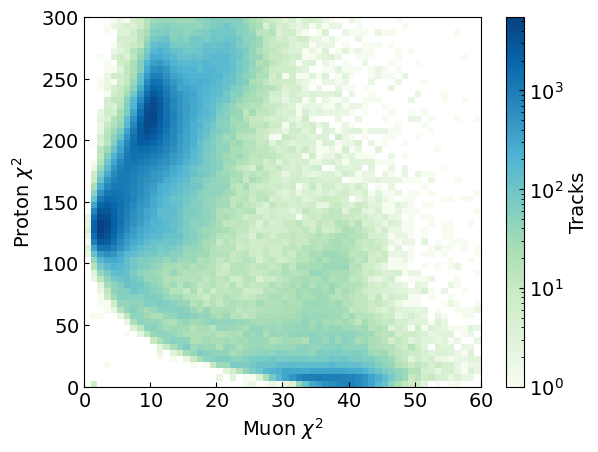

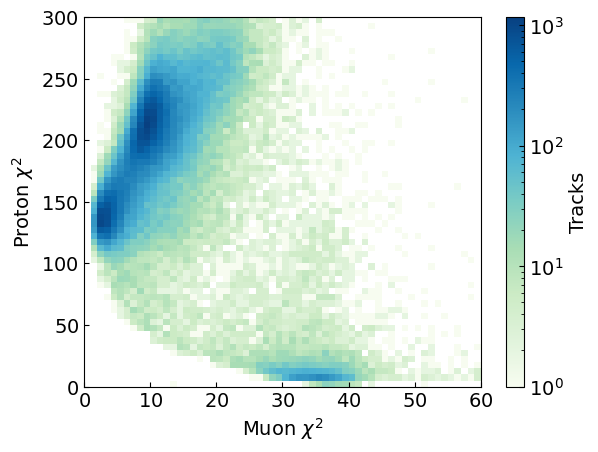

In [13]:
# compare chi2_mu vs. chi2_p 2D distributions and get the percentage out of total of the selected area
from matplotlib.colors import LogNorm

var_config_1 = VariableConfig.chi2_mu()
var_config_2 = VariableConfig.chi2_proton()

var_1 = avg_chi2(mc_evt_df.trk1, "chi2_muon")
var_2 = avg_chi2(mc_evt_df.trk1, "chi2_proton")

plt.hist2d(var_1, 
           var_2, 
           bins=[var_config_1.bins, var_config_2.bins],
           cmap="GnBu", norm=LogNorm())
plt.colorbar(label="Tracks")
plt.xlabel("Muon $\\chi^2$")
plt.ylabel("Proton $\\chi^2$")
# plt.plot([MU_CHI2MU_TH, MU_CHI2MU_TH], [MU_CHI2P_TH, var_config_2.bins[-1]], color="red", linestyle="--")
# plt.plot([0,MU_CHI2MU_TH], [MU_CHI2P_TH,MU_CHI2P_TH], color="red", linestyle="--")

# plt.text(0.025, 1.07, r"Simulation", transform=plt.gca().transAxes, fontsize=14, color='gray', ha='left', va='top')
if save_fig:
    save_name = save_fig_dir + "/chi2muon_vs_chi2proton-MC-trk1.pdf"
    plt.savefig(save_name, bbox_inches="tight")
plt.show()

var_1 = avg_chi2(data_evt_df.trk1, "chi2_muon")
var_2 = avg_chi2(data_evt_df.trk1, "chi2_proton")

plt.hist2d(var_1, 
           var_2, 
           bins=[var_config_1.bins, var_config_2.bins],
           cmap="GnBu", norm=LogNorm())
plt.colorbar(label="Tracks")
plt.xlabel("Muon $\\chi^2$")
plt.ylabel("Proton $\\chi^2$")
# plt.plot([MU_CHI2MU_TH, MU_CHI2MU_TH], [MU_CHI2P_TH, var_config_2.bins[-1]], color="red", linestyle="--")
# plt.plot([0,MU_CHI2MU_TH], [MU_CHI2P_TH,MU_CHI2P_TH], color="red", linestyle="--")
# plt.text(0.025, 1.07, r"$\mathbf{SBND}$ Preliminary    $\mathbf{SBND}$ Data", transform=plt.gca().transAxes, fontsize=14, color='gray', ha='left', va='top')
# plt.text(0.025, 1.07, r"Data", transform=plt.gca().transAxes, fontsize=14, color='gray', ha='left', va='top')
if save_fig:
    save_name = save_fig_dir + "/chi2muon_vs_chi2proton-data-trk1.pdf"
    plt.savefig(save_name, bbox_inches="tight")
plt.show()

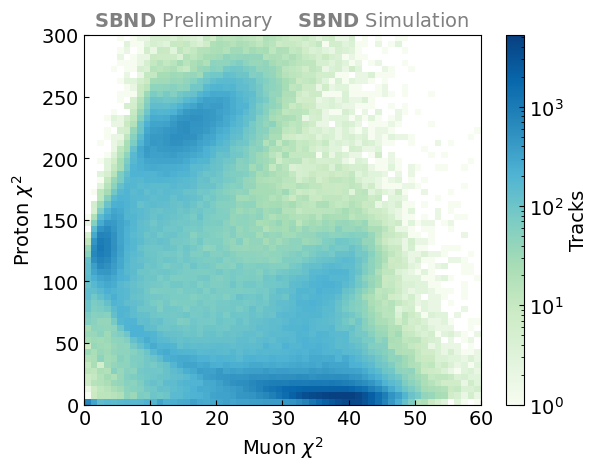

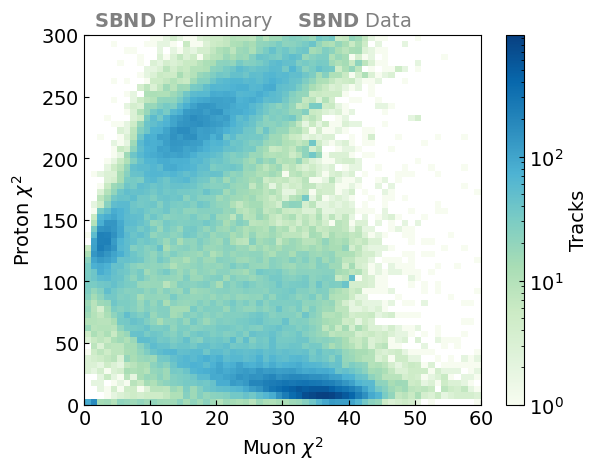

In [ ]:
var_config_1 = VariableConfig.chi2_mu()
var_config_2 = VariableConfig.chi2_proton()

var_1 = avg_chi2(mc_evt_df.trk2, "chi2_muon")
var_2 = avg_chi2(mc_evt_df.trk2, "chi2_proton")

plt.hist2d(var_1, 
           var_2, 
           bins=[var_config_1.bins, var_config_2.bins],
           cmap="GnBu", norm=LogNorm())
plt.colorbar(label="Tracks")
plt.xlabel("Muon $\\chi^2$")
plt.ylabel("Proton $\\chi^2$")
# plt.plot([MU_CHI2MU_TH, MU_CHI2MU_TH], [MU_CHI2P_TH, var_config_2.bins[-1]], color="red", linestyle="--")
# plt.plot([0,MU_CHI2MU_TH], [MU_CHI2P_TH,MU_CHI2P_TH], color="red", linestyle="--")

# plt.text(0.025, 1.07, r"$\mathbf{SBND}$ Preliminary    $\mathbf{SBND}$ Simulation", transform=plt.gca().transAxes, fontsize=14, color='gray', ha='left', va='top')
if save_fig:
    save_name = save_fig_dir + "/chi2muon_vs_chi2proton-MC-trk2.pdf"
    plt.savefig(save_name, bbox_inches="tight")
plt.show()

var_1 = avg_chi2(data_evt_df.trk2, "chi2_muon")
var_2 = avg_chi2(data_evt_df.trk2, "chi2_proton")

plt.hist2d(var_1, 
           var_2, 
           bins=[var_config_1.bins, var_config_2.bins],
           cmap="GnBu", norm=LogNorm())
plt.colorbar(label="Tracks")
plt.xlabel("Muon $\\chi^2$")
plt.ylabel("Proton $\\chi^2$")
# plt.plot([MU_CHI2MU_TH, MU_CHI2MU_TH], [MU_CHI2P_TH, var_config_2.bins[-1]], color="red", linestyle="--")
# plt.plot([0,MU_CHI2MU_TH], [MU_CHI2P_TH,MU_CHI2P_TH], color="red", linestyle="--")
# plt.text(0.025, 1.07, r"$\mathbf{SBND}$ Preliminary    $\mathbf{SBND}$ Data", transform=plt.gca().transAxes, fontsize=14, color='gray', ha='left', va='top')
if save_fig:
    save_name = save_fig_dir + "/chi2muon_vs_chi2proton-data-trk2.pdf"
    plt.savefig(save_name, bbox_inches="tight")
plt.show()

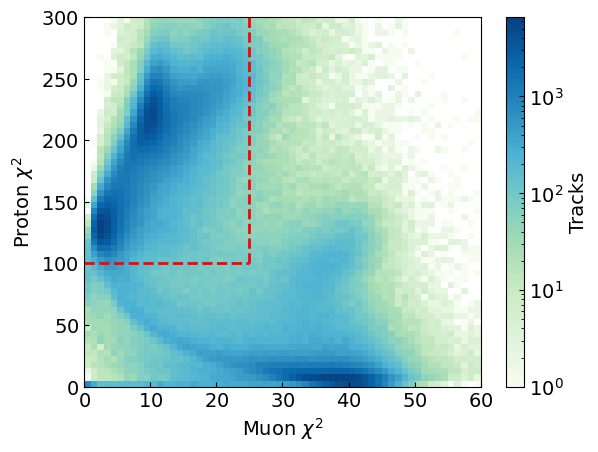

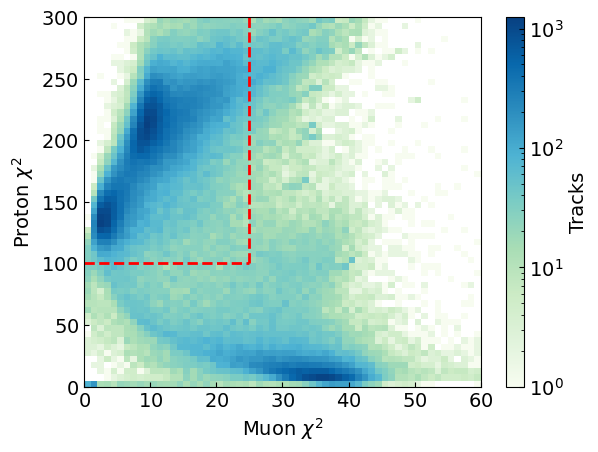

In [14]:
var_config_1 = VariableConfig.chi2_mu()
var_config_2 = VariableConfig.chi2_proton()

var_1_trk1 = avg_chi2(mc_evt_df.trk1, "chi2_muon").to_numpy(dtype=float)
var_2_trk1 = avg_chi2(mc_evt_df.trk1, "chi2_proton").to_numpy(dtype=float)
var_1_trk2 = avg_chi2(mc_evt_df.trk2, "chi2_muon").to_numpy(dtype=float)
var_2_trk2 = avg_chi2(mc_evt_df.trk2, "chi2_proton").to_numpy(dtype=float)
var_1 = np.concatenate([var_1_trk1, var_1_trk2])
var_2 = np.concatenate([var_2_trk1, var_2_trk2])

plt.hist2d(var_1, 
           var_2, 
           bins=[var_config_1.bins, var_config_2.bins],
           cmap="GnBu", norm=LogNorm())
plt.colorbar(label="Tracks")
plt.xlabel("Muon $\\chi^2$")
plt.ylabel("Proton $\\chi^2$")
plt.plot([MU_CHI2MU_TH, MU_CHI2MU_TH], [MU_CHI2P_TH, var_config_2.bins[-1]], color="red", linestyle="--")
plt.plot([0,MU_CHI2MU_TH], [MU_CHI2P_TH,MU_CHI2P_TH], color="red", linestyle="--")

# plt.text(0.025, 1.07, r"$\mathbf{SBND}$ Preliminary    $\mathbf{SBND}$ Simulation", transform=plt.gca().transAxes, fontsize=14, color='gray', ha='left', va='top')
if save_fig:
    save_name = save_fig_dir + "/chi2muon_vs_chi2proton-MC-wcuts.pdf"
    plt.savefig(save_name, bbox_inches="tight")
plt.show()

var_1_trk1 = avg_chi2(data_evt_df.trk1, "chi2_muon")
var_2_trk1 = avg_chi2(data_evt_df.trk1, "chi2_proton")
var_1_trk2 = avg_chi2(data_evt_df.trk2, "chi2_muon")
var_2_trk2 = avg_chi2(data_evt_df.trk2, "chi2_proton")
var_1 = np.concatenate([var_1_trk1, var_1_trk2])
var_2 = np.concatenate([var_2_trk1, var_2_trk2])

plt.hist2d(var_1, 
           var_2, 
           bins=[var_config_1.bins, var_config_2.bins],
           cmap="GnBu", norm=LogNorm())
plt.colorbar(label="Tracks")
plt.xlabel("Muon $\\chi^2$")
plt.ylabel("Proton $\\chi^2$")
plt.plot([MU_CHI2MU_TH, MU_CHI2MU_TH], [MU_CHI2P_TH, var_config_2.bins[-1]], color="red", linestyle="--")
plt.plot([0,MU_CHI2MU_TH], [MU_CHI2P_TH,MU_CHI2P_TH], color="red", linestyle="--")
# plt.text(0.025, 1.07, r"$\mathbf{SBND}$ Preliminary    $\mathbf{SBND}$ Data", transform=plt.gca().transAxes, fontsize=14, color='gray', ha='left', va='top')
if save_fig:
    save_name = save_fig_dir + "/chi2muon_vs_chi2proton-data-wcuts.pdf"
    plt.savefig(save_name, bbox_inches="tight")
plt.show()

In [15]:
save_fig_dir

'/exp/sbnd/data/users/munjung/plots/numucc1p0pi/PID_thesis'